### 1/ Import libraries

In [1]:
%matplotlib widget
from filereaders import h5File_SWING
from saxsprocessor import SAXSProcessor
import numpy as np
import os
import glob
import matplotlib.pyplot as plt

### 2/ Load and convert Swing mask

In [2]:
maskfile = './mask_hamon_6m_ex_apr25.txt'
datafile = './paineau_00187_0V.h5'

# create h5File_SWING instance to convert mask
swingfile = h5File_SWING(datafile,mean=True)
swingfile.convert_SWING_mask(maskfile)
print(f'The file contains:\n - {swingfile.nb_frames} images \n - {swingfile.num_pixel_z}')


Mask file was successfully imported and converted in ./mask_pyfai.edf
The file contains:
 - 1 images 
 - 1035


### 3/ Create SAXSProcessor instance

In [3]:
proc = SAXSProcessor(datafile,instrument='SWING',mask='./mask_pyfai.edf')

print(f'pix_size*center : {proc.pixel_size_x*proc.x_center},{proc.pixel_size_z*proc.z_center}')
#proc.plot2d_vsq(q_range = [0,0.05])

Initial pixel size: 7.5e-05x7.5e-05
Due to binning, pixel size was modified to 0.00015x0.00015
pix_size*center : 0.042637081908696174,0.10468432298831631


To identify the main axis of the pattern, we extract the azimuthal profile and search for the maximum

The pattern main axis is oriented at 33.06135090567369°


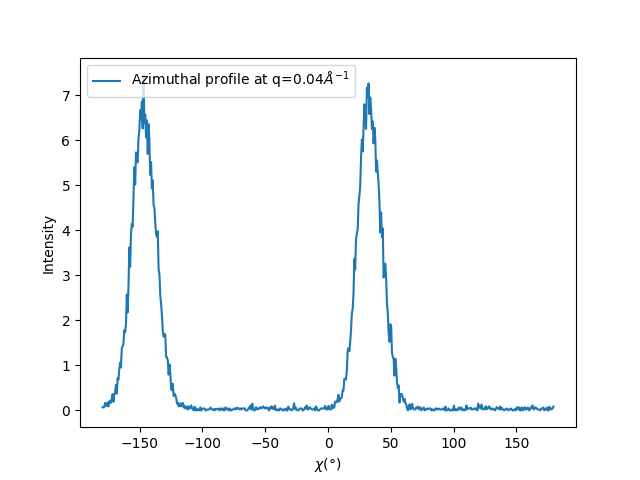

In [4]:
chi,I = proc.extract_azimuthal_profile(qvalue=0.04,threshold=0.05)

chimax= (chi[np.argmax(I)] + 90) % 180 - 90 

print(f'The pattern main axis is oriented at {chimax}°')


plt.figure()
plt.plot(chi,I,label='Azimuthal profile at q=$0.04\AA^{-1} $')
plt.xlabel('$\chi (°)$')
plt.ylabel('Intensity')
plt.legend()


We can now extract the radial profile along this azimuth

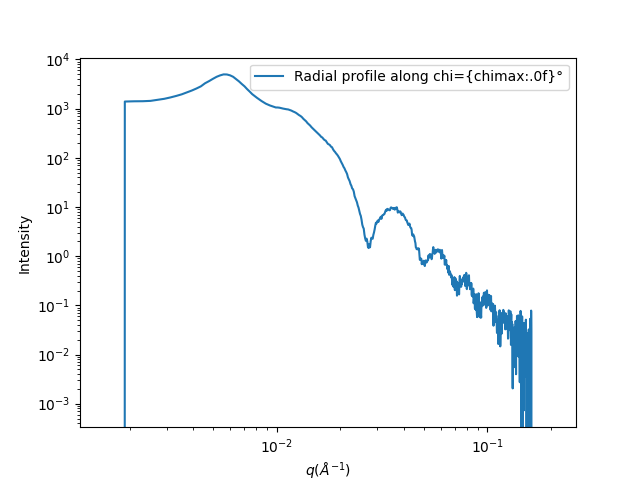

In [5]:
q,I = proc.extract_radial_profile(azimuth=chimax, width = 10)
plt.figure()
plt.loglog(q,I, label='Radial profile along chi={chimax:.0f}°')
plt.xlabel('$q (\AA^{-1}) $')
plt.ylabel('Intensity')
plt.legend()


Conversion to sasview 2D format, user specified q_range

In [6]:
proc.export_sasview(q_range=[0,0.1])

Export to SASView 2D format in : ./sasview_exports//0V_187.dat


### Batch version for sasview export

Here we will convert all files to sasview format.

In [7]:
from filereaders import h5File_SWING
from saxsprocessor import SAXSProcessor
import glob
import os

### Define file list

This is done using glob and os libraries

In [8]:
path = './'
filelist = glob.glob(os.path.join(path,'*.h5'))  
print (filelist)

['./paineau_00194_76V.h5', './paineau_00187_0V.h5', './paineau_00195_180V.h5', './paineau_00193_36V.h5', './paineau_00191_13V.h5']


### sort list by file number

In [9]:
def extract_number(file):
    return int(file.split('/')[-1].split('.')[0].split('_')[1])

filelist = sorted(filelist, key=extract_number)

print(filelist)

['./paineau_00187_0V.h5', './paineau_00191_13V.h5', './paineau_00193_36V.h5', './paineau_00194_76V.h5', './paineau_00195_180V.h5']


### Mask conversion

This step is crucial for SAXSProcessor to work. The initial format provided on SWING is not compatible with pyFAI. We therefore need to convert it. This the same procedure as the one decribes above.

In [10]:
maskfile = './mask_hamon_6m_ex_apr25.txt'
datafile = filelist[0]

# create h5File_SWING instance to convert mask
swingfile = h5File_SWING(datafile,mean=True)
mask = swingfile.convert_SWING_mask(maskfile)


Mask file was successfully imported and converted in ./mask_pyfai.edf


### Export to sasview

done using export_sasview method from SAXSPRocessor instance, for each file in the list

In [11]:
# defin q range for sasview export
q_range= [0, 0.1]

for file in filelist:
    proc = SAXSProcessor(file=file,instrument='SWING',mask=mask)
    proc.export_sasview(q_range=q_range)



Initial pixel size: 7.5e-05x7.5e-05
Due to binning, pixel size was modified to 0.00015x0.00015
Export to SASView 2D format in : ./sasview_exports//0V_187.dat
Initial pixel size: 7.5e-05x7.5e-05
Due to binning, pixel size was modified to 0.00015x0.00015
Export to SASView 2D format in : ./sasview_exports//1V_191.dat
Initial pixel size: 7.5e-05x7.5e-05
Due to binning, pixel size was modified to 0.00015x0.00015
Export to SASView 2D format in : ./sasview_exports//2V_193.dat
Initial pixel size: 7.5e-05x7.5e-05
Due to binning, pixel size was modified to 0.00015x0.00015
Export to SASView 2D format in : ./sasview_exports//5V_194.dat
Initial pixel size: 7.5e-05x7.5e-05
Due to binning, pixel size was modified to 0.00015x0.00015
Export to SASView 2D format in : ./sasview_exports//10V_195.dat
